# SQL Agent with LangGraph — Walmart Sales
**Goal:** Introduction to LangGraph DAGs (Directed Acyclic Graphs) for SQL querying on Walmart Sales data

## Libraries

In [1]:
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from langchain_classic.chains import create_sql_query_chain

# LangGraph
from langgraph.graph import END, StateGraph
from typing import TypedDict

import pandas as pd
import sqlalchemy as sql
import os
import re
import yaml
from pprint import pprint

C:\Users\User\AppData\Local\Temp\ipykernel_14060\1179844273.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


## AI Setup

In [2]:
os.environ["OPENAI_API_KEY"] = yaml.safe_load(open('../credentials.yml'))['openai']

llm = ChatOpenAI(model="gpt-4o-mini")

## 1.0 SQL Agent — Walmart Sales Database

In [3]:
PATH_DB = "sqlite:///../data/walmart_sales.db"

sql_engine = sql.create_engine(PATH_DB)
conn = sql_engine.connect()

db = SQLDatabase.from_uri(PATH_DB)

sql_generator = create_sql_query_chain(
    llm=llm,
    db=db,
    k=int(1e7),  # Set high to avoid LIMIT truncation
)

print("Tables:", db.get_usable_table_names())

Tables: ['daily_demand']


## 2.0 SQL Parsing Utility

In [4]:
def extract_sql_code(text: str):
    """Extract the SQL query from an LLM response. Returns None if not found."""
    if not text:
        return None
    for pat in [
        r"SQLQuery:\s*```sql\s*([\s\S]+?)```",
        r"```sql\s*([\s\S]+?)```",
        r"```[\w]*\s*(SELECT[\s\S]+?)```",
        r"SQLQuery:\s*(SELECT[\s\S]+?)(?:\n\n|$)",
        r"(SELECT[\s\S]+?)(?:;|\n\n|$)",
    ]:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            return m.group(1).strip().rstrip(";")
    return None

In [5]:
# Test the SQL generator directly
response = sql_generator.invoke({"question": "What are the top 10 items ranked by total cumulative demand value?"})
sql_q = extract_sql_code(response)
pprint(sql_q)
pd.read_sql(sql_q, conn)

('SELECT "item_id", SUM("value") AS "total_demand" \n'
 'FROM "daily_demand" \n'
 'GROUP BY "item_id" \n'
 'ORDER BY "total_demand" DESC \n'
 'LIMIT 10')


,item_id,total_demand
0,FOODS_3_090,1002529
1,FOODS_3_586,920242
2,FOODS_3_252,565299
3,FOODS_3_555,491287
4,FOODS_3_714,396172
5,FOODS_3_587,396119
6,FOODS_3_694,390001
7,FOODS_3_226,363082
8,FOODS_3_202,295689
9,FOODS_3_723,284333


## 3.0 Build a LangGraph DAG

In [6]:
class GraphState(TypedDict):
    """Represents the state of our graph."""
    question: str
    sql_query: str

In [7]:
def generate_sql(state):
    print("---GENERATE SQL---")
    question = state.get("question")
    sql_query = sql_generator.invoke({"question": question})
    sql_query = extract_sql_code(sql_query)
    return {"sql_query": sql_query}

In [8]:
def state_printer(state):
    """Print the state."""
    print("---STATE PRINTER---")
    print(f"question: {state.get('question')}")
    pprint(f"SQL Query:\n{state.get('sql_query')}")

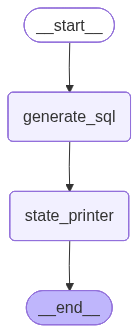

In [9]:
workflow = StateGraph(GraphState)

workflow.add_node("generate_sql", generate_sql)
workflow.add_node("state_printer", state_printer)

workflow.set_entry_point("generate_sql")
workflow.add_edge("generate_sql", "state_printer")
workflow.add_edge("state_printer", END)

app = workflow.compile()
app

## 4.0 Testing the Graph

In [10]:
QUESTION = "What are the top 10 items by total cumulative demand value?"

response = app.invoke({"question": QUESTION})
print("SQL:", response['sql_query'])
db.run(response['sql_query'])

---GENERATE SQL---


---STATE PRINTER---
question: What are the top 10 items by total cumulative demand value?
('SQL Query:\n'
 'SELECT "item_id", SUM("value") AS "total_demand"\n'
 'FROM "daily_demand"\n'
 'GROUP BY "item_id"\n'
 'ORDER BY "total_demand" DESC\n'
 'LIMIT 10')
SQL: SELECT "item_id", SUM("value") AS "total_demand"
FROM "daily_demand"
GROUP BY "item_id"
ORDER BY "total_demand" DESC
LIMIT 10


"[('FOODS_3_090', 1002529), ('FOODS_3_586', 920242), ('FOODS_3_252', 565299), ('FOODS_3_555', 491287), ('FOODS_3_714', 396172), ('FOODS_3_587', 396119), ('FOODS_3_694', 390001), ('FOODS_3_226', 363082), ('FOODS_3_202', 295689), ('FOODS_3_723', 284333)]"

In [11]:
QUESTION = "What is the total demand value grouped by year and month? Order chronologically."

response = app.invoke({"question": QUESTION})
sql_q = response.get("sql_query")
pprint(sql_q)
pd.read_sql(sql_q, conn)

---GENERATE SQL---


---STATE PRINTER---
question: What is the total demand value grouped by year and month? Order chronologically.
('SQL Query:\n'
 'SELECT strftime(\'%Y-%m\', "date") AS "year_month", SUM("value") AS '
 '"total_demand"\n'
 'FROM daily_demand\n'
 'GROUP BY "year_month"\n'
 'ORDER BY "year_month" ASC')
('SELECT strftime(\'%Y-%m\', "date") AS "year_month", SUM("value") AS '
 '"total_demand"\n'
 'FROM daily_demand\n'
 'GROUP BY "year_month"\n'
 'ORDER BY "year_month" ASC')


,year_month,total_demand
0,2011-01,9758
1,2011-02,69217
2,2011-03,64767
3,2011-04,69084
4,2011-05,69958
...,...,...
59,2015-12,70503
60,2016-01,80705
61,2016-02,88471
62,2016-03,89161


In [12]:
QUESTION = "What is the average daily demand value per item_id? Return top 15 items ordered by average descending."

response = app.invoke({"question": QUESTION})
sql_q = response.get("sql_query")
pprint(sql_q)
pd.read_sql(sql_q, conn)

---GENERATE SQL---


---STATE PRINTER---
question: What is the average daily demand value per item_id? Return top 15 items ordered by average descending.
('SQL Query:\n'
 'SELECT "item_id", AVG("value") AS "average_demand" FROM daily_demand GROUP '
 'BY "item_id" ORDER BY "average_demand" DESC LIMIT 15')
('SELECT "item_id", AVG("value") AS "average_demand" FROM daily_demand GROUP '
 'BY "item_id" ORDER BY "average_demand" DESC LIMIT 15')


,item_id,average_demand
0,FOODS_3_090,524.061160
1,FOODS_3_586,481.046524
2,FOODS_3_252,295.503921
3,FOODS_3_555,256.814950
4,FOODS_3_714,207.094616
5,FOODS_3_587,207.066911
6,FOODS_3_694,203.868792
7,FOODS_3_226,189.797177
8,FOODS_3_202,154.568217
9,FOODS_3_723,148.631992


In [13]:
QUESTION = "Which item had the single highest daily demand value, and on what date?"

response = app.invoke({"question": QUESTION})
sql_q = response.get("sql_query")
pprint(sql_q)
pd.read_sql(sql_q, conn)

---GENERATE SQL---


---STATE PRINTER---
question: Which item had the single highest daily demand value, and on what date?
('SQL Query:\n'
 'SELECT "item_id", "value", "date" FROM daily_demand ORDER BY "value" DESC '
 'LIMIT 1')
('SELECT "item_id", "value", "date" FROM daily_demand ORDER BY "value" DESC '
 'LIMIT 1')


,item_id,value,date
0,FOODS_3_090,2532,2013-09-01


In [14]:
QUESTION = "What are the top 5 items by total demand value in 2015?"

response = app.invoke({"question": QUESTION})
sql_q = response.get("sql_query")
pprint(sql_q)
pd.read_sql(sql_q, conn)

---GENERATE SQL---


---STATE PRINTER---
question: What are the top 5 items by total demand value in 2015?
('SQL Query:\n'
 'SELECT "item_id", SUM("value") AS "total_demand" FROM "daily_demand" WHERE '
 'date BETWEEN \'2015-01-01\' AND \'2015-12-31\' GROUP BY "item_id" ORDER BY '
 '"total_demand" DESC LIMIT 5')
('SELECT "item_id", SUM("value") AS "total_demand" FROM "daily_demand" WHERE '
 'date BETWEEN \'2015-01-01\' AND \'2015-12-31\' GROUP BY "item_id" ORDER BY '
 '"total_demand" DESC LIMIT 5')


,item_id,total_demand
0,FOODS_3_586,162918
1,FOODS_3_090,157275
2,FOODS_3_252,110849
3,FOODS_3_120,94404
4,FOODS_3_587,91954


In [15]:
conn.close()